### This notebook is used to plot the training metrics and also compare different runs. It is not used for training or evaluation. It is just for visualization and analysis of the training results

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import os

In [5]:
def load_metrics(metrics_path):
    with open(metrics_path, 'r') as f:
        metrics = None
        losses_key = None
        for i, line in enumerate(f):
            metrics_dict = json.loads(line)
            dtype = [(key, type(metrics_dict[key])) for key in metrics_dict.keys()]
            # print(dtype)
            if i==0:
                metrics = np.array([tuple(metrics_dict.values())], dtype=dtype)
                losses_key = [f for f in metrics_dict.keys() if '_loss' in f]
            else:
                metrics = np.append(metrics, np.array([tuple(metrics_dict.values())], dtype=dtype), axis=0)
    return metrics, losses_key


In [6]:
path_to_original_dino = '/nfs/data/1/rrazakami/work/OUTPUT_DINO/training_dinov2/output_Feb12_2026_originalDINO/training_metrics.json'
path_to_modified_dino = '/nfs/data/1/nitish/dino_output/cvn_properrun_1gpu/training_metrics.json'

In [7]:
original_dino_metrics, loss_keys = load_metrics(path_to_original_dino)
modified_dino_metrics, loss_keys_modified = load_metrics(path_to_modified_dino)

In [59]:
loss_keys_modified

['total_loss',
 'dino_local_crops_loss',
 'dino_global_crops_loss',
 'koleo_loss',
 'ibot_loss']

In [56]:
def plot_comparison_losses(original_dino_metrics, modified_dino_metrics, loss_keys, zoom_on_iteration=False):
    fig, axes = plt.subplots(3, 2, figsize=(8*2, 6*3))
    min_iteration = min(original_dino_metrics['iteration'].max(), modified_dino_metrics['iteration'].max())
    for i, k in enumerate(loss_keys):
        if i < 6:  # Only plot first 6 losses (3x2 = 6 subplots)
            row = i // 2  # Calculate row index
            col = i % 2   # Calculate column index
            axes[row, col].plot(original_dino_metrics['iteration'], original_dino_metrics[k], label=k+'_original DINO', linestyle='-')
            axes[row, col].plot(modified_dino_metrics['iteration'], modified_dino_metrics[k], label=k+'_modified DINO', linestyle='--')
            axes[row, col].set_xlabel('Iteration', fontsize=20)
            axes[row, col].set_ylabel('loss', fontsize=20)
            axes[row, col].tick_params(axis='both', labelsize=20)
            if zoom_on_iteration:
                axes[row, col].set_xlim(-1000, min_iteration)
            axes[row, col].grid(True)
            axes[row, col].legend(fontsize=20, loc='center')

    # Hide empty subplots if you have fewer than 6 losses
    for i in range(len(loss_keys), 6):
        row = i // 2
        col = i % 2
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

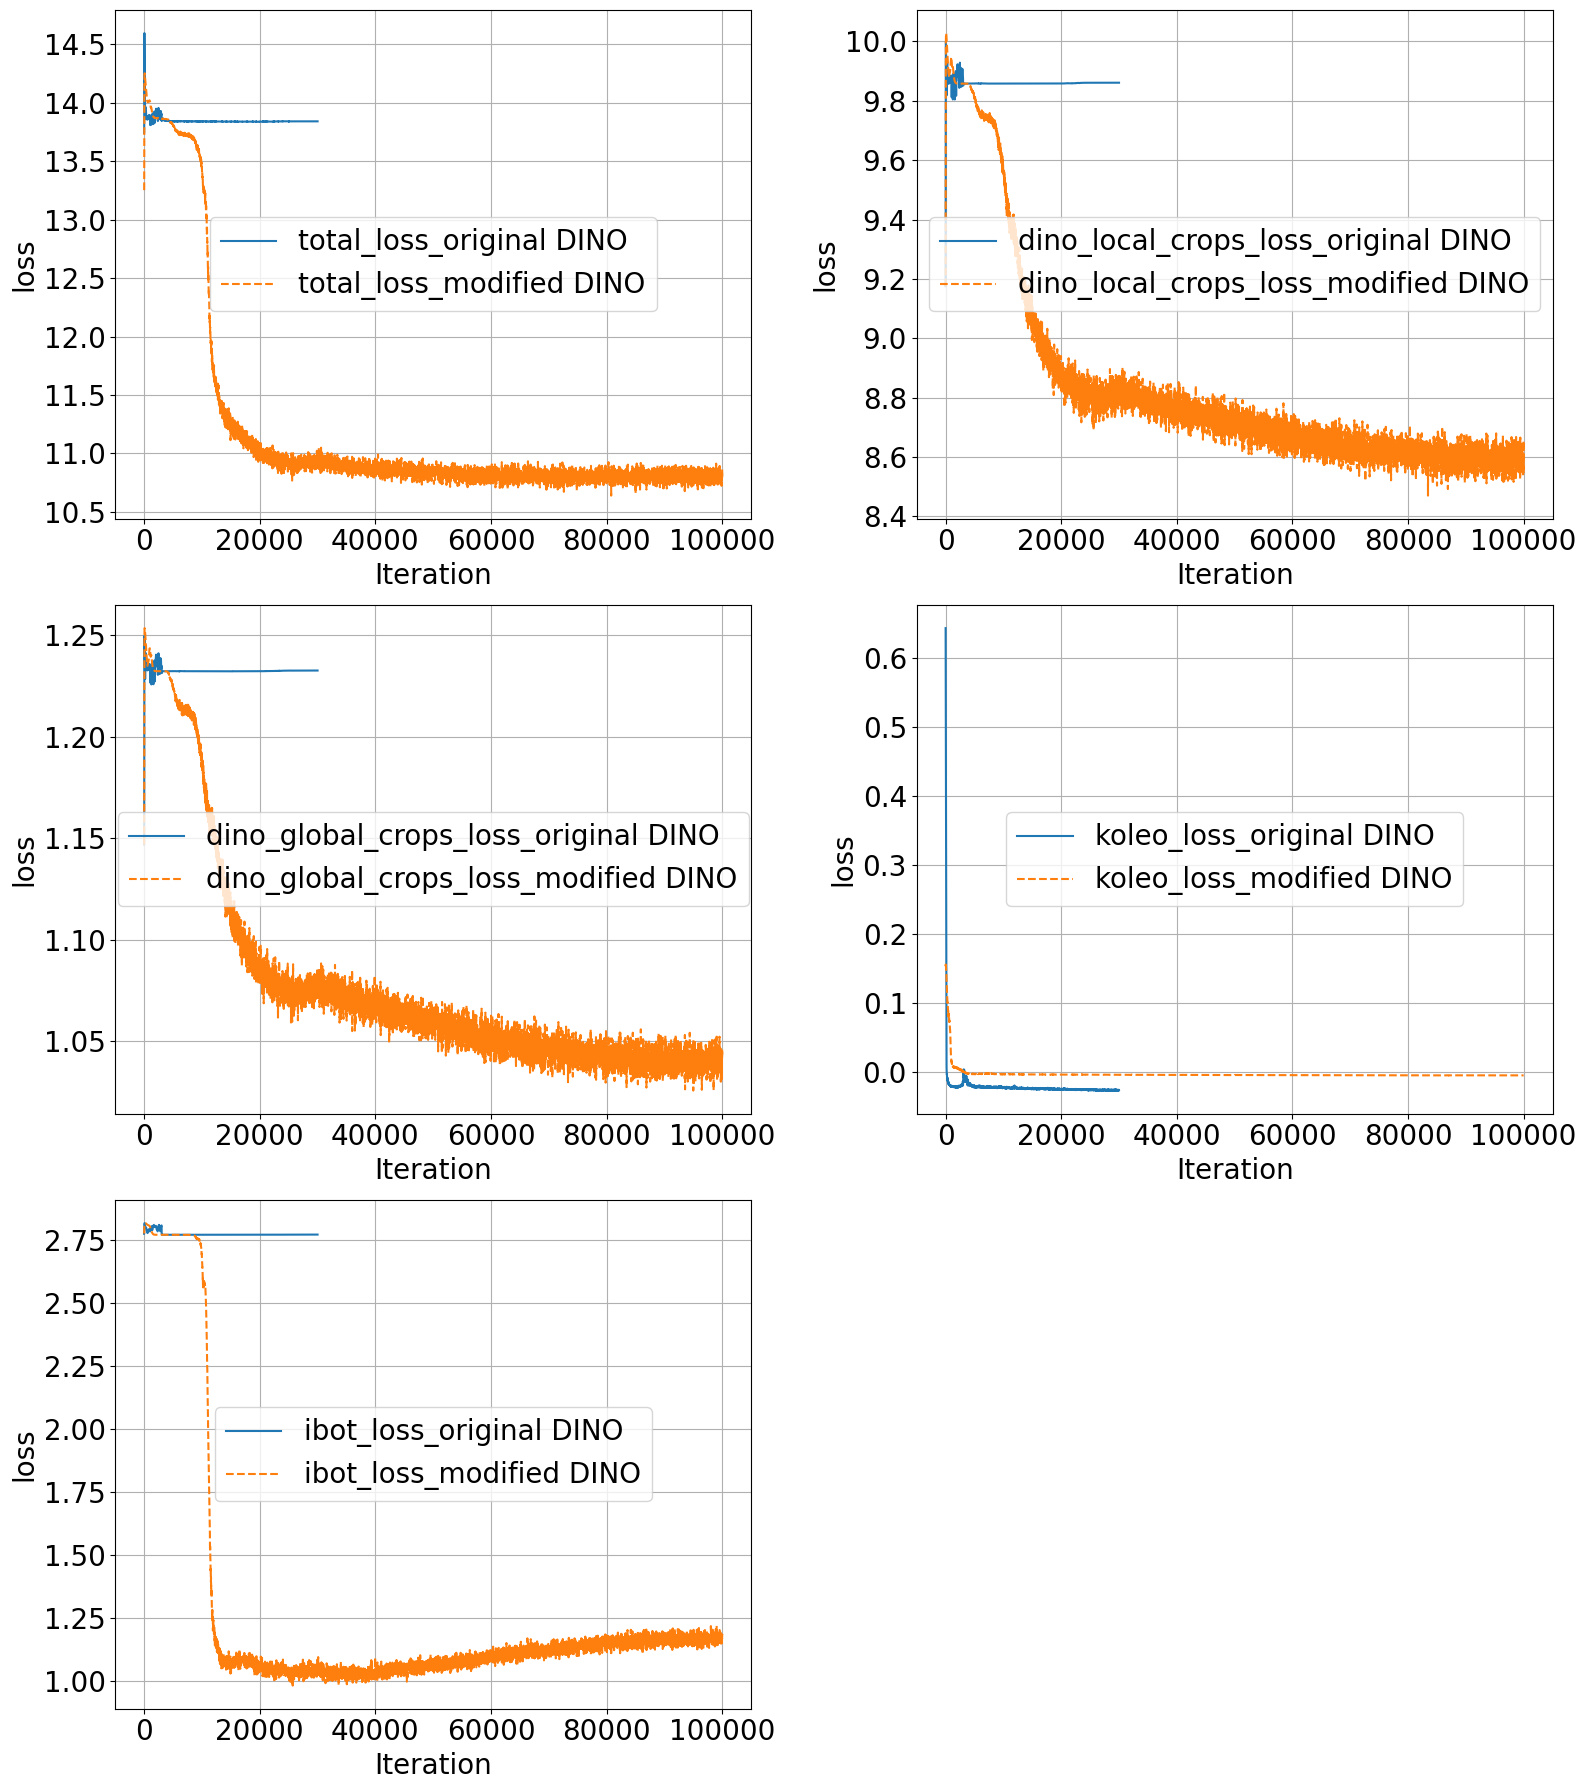

In [57]:
plot_comparison_losses(original_dino_metrics, modified_dino_metrics, loss_keys)

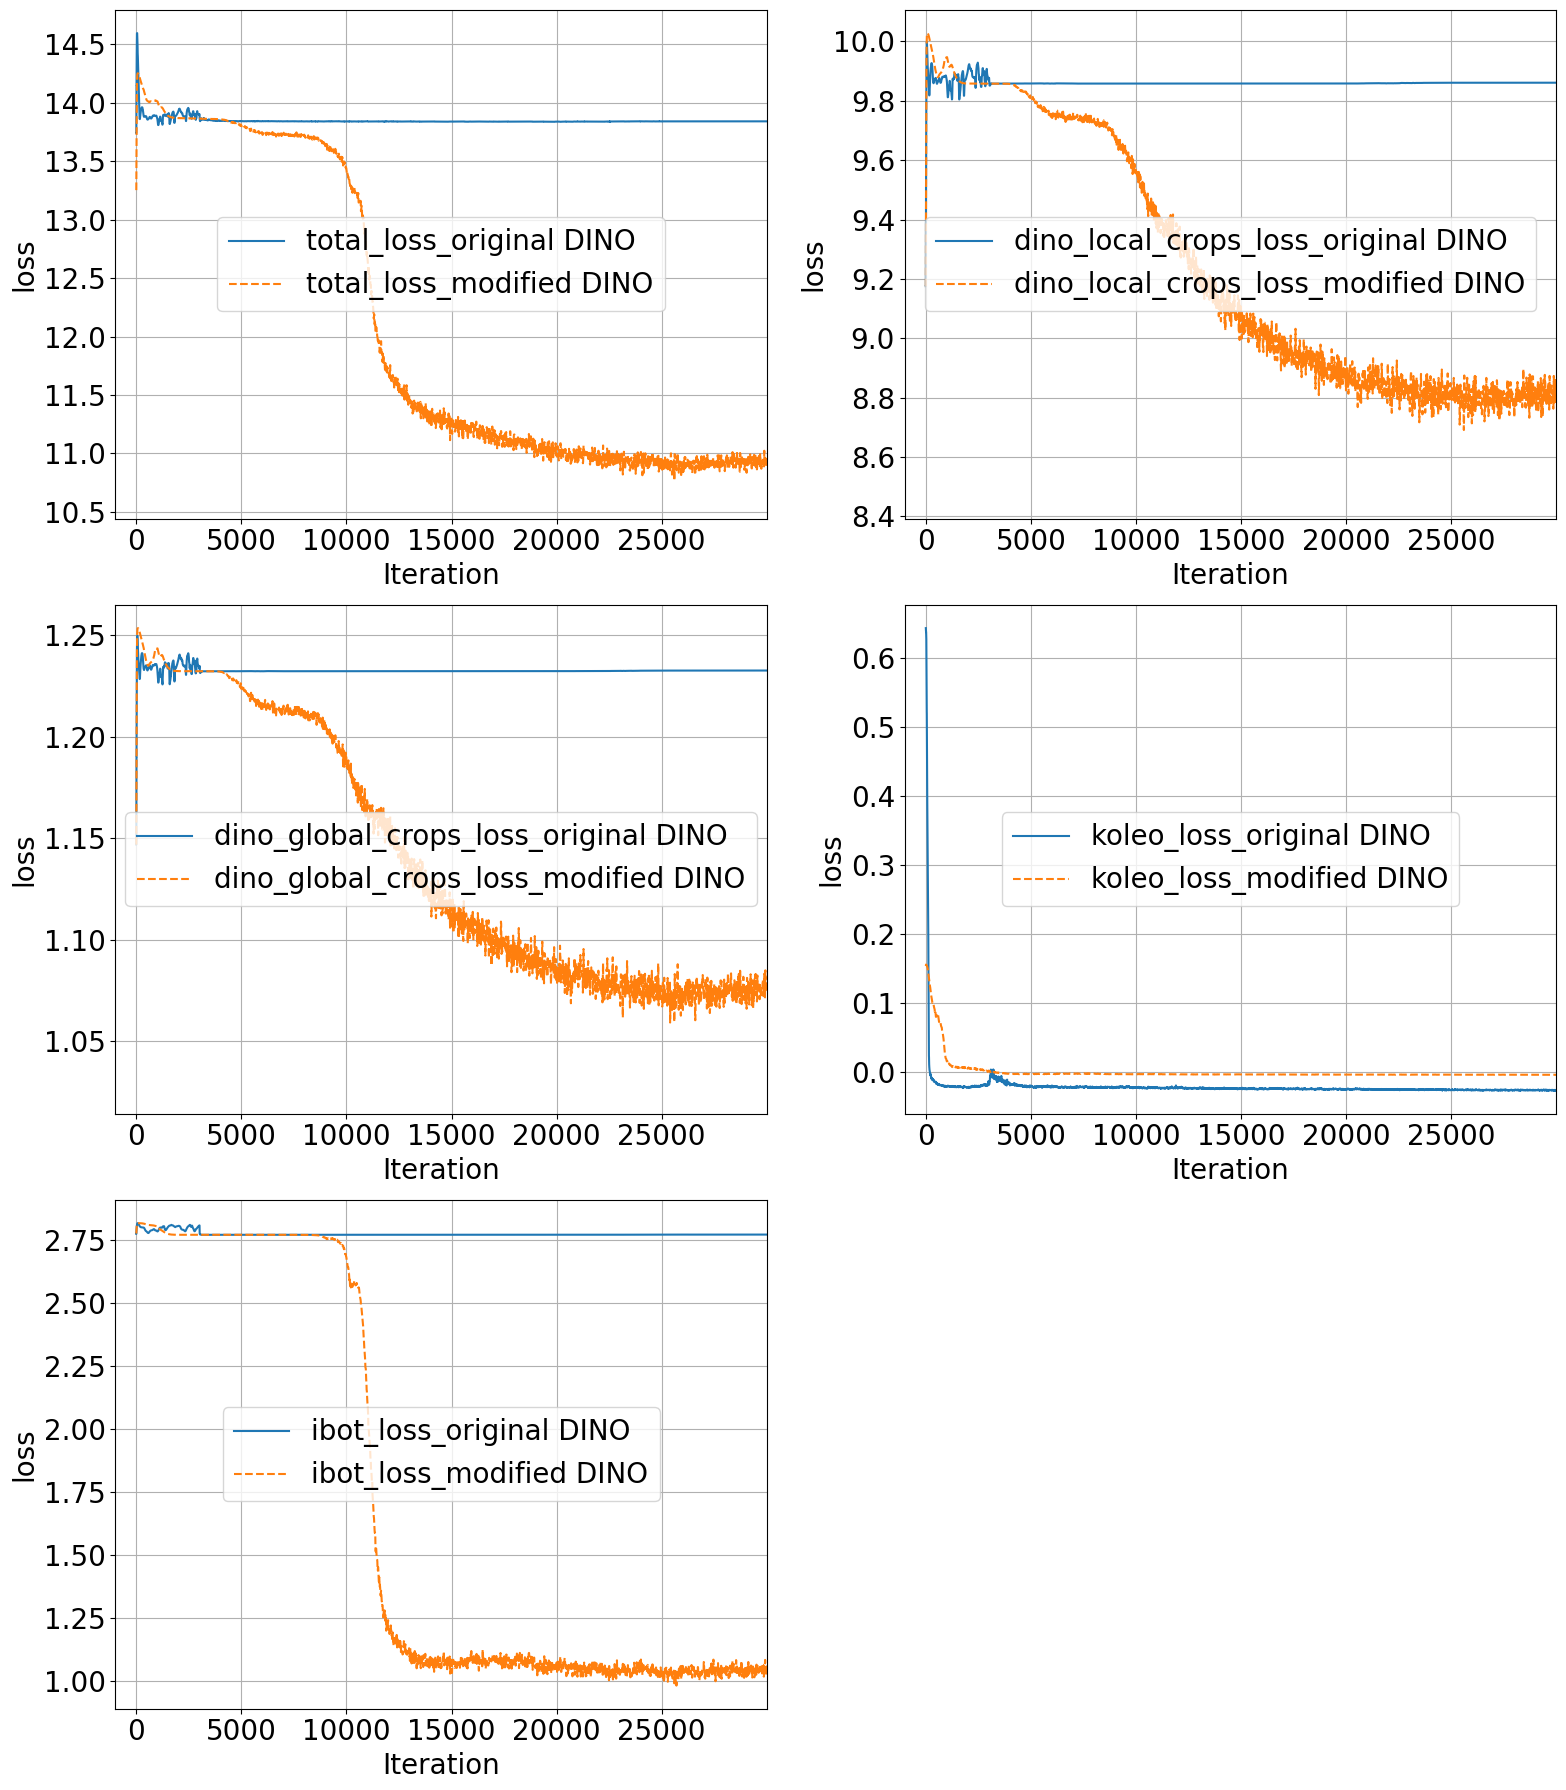

In [58]:
plot_comparison_losses(original_dino_metrics, modified_dino_metrics, loss_keys, True)